In [1]:
from model import TeacherModel, StudentModel1, StudentModel2
from test_dataset import RDataset
import torch
import torch.optim as optim
import torch.nn as nn
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import random

In [2]:
random.seed(228)

In [3]:
def dataset_loader(observ, actions, targets):
    transform = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
    
    # train/val (80/20)
    N = len(observ)
    indices = np.random.permutation(N)
    split = int(0.8 * N)
    train_idx, val_idx = indices[:split], indices[split:]
    
    train_dataset = RDataset(observ[train_idx], actions[train_idx], targets[train_idx], transform)
    val_dataset   = RDataset(observ[val_idx],   actions[val_idx], targets[val_idx], transform)
    
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    return train_loader, val_loader, train_dataset, val_dataset

In [4]:
def distill_model(teacher, student, observ, actions, targets, name,
                  modality=True, alpha=0.7, num_epochs=10, lr=3e-4):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    student = student.to(device)

    mse_loss = nn.MSELoss()
    optimizer = optim.Adam(student.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    train_loader, val_loader, train_dataset, val_dataset = dataset_loader(
        observ, actions, targets
    )
    train_score, val_score = [], []


    for epoch in range(num_epochs):
        student.train()
        train_kd_loss = 0.0
        train_bc_loss = 0.0
        train_total_loss = 0.0

        for imgs, acts, target in train_loader:
            imgs = imgs.to(device)
            target = target.to(device)
            acts = acts.to(device)

            with torch.no_grad():
                teacher_outputs = teacher(imgs, target)

            student_outputs = student(imgs, target) if modality else student(imgs)

            loss_kd = mse_loss(student_outputs, teacher_outputs)
            loss_bc = mse_loss(student_outputs, acts)
            loss = alpha * loss_kd + (1 - alpha) * loss_bc

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=5.0)
            optimizer.step()

            train_kd_loss += loss_kd.item() * imgs.size(0)
            train_bc_loss += loss_bc.item() * imgs.size(0)
            train_total_loss += loss.item() * imgs.size(0)

        n_train = len(train_dataset)
        train_kd_loss /= n_train
        train_bc_loss /= n_train
        train_total_loss /= n_train
        train_score.append(train_total_loss)

        student.eval()
        val_total = 0.0
        with torch.no_grad():
            for imgs, acts, target in val_loader:
                imgs, target, acts = imgs.to(device), target.to(device), acts.to(device)
                teacher_output = teacher(imgs, target)
                student_output = student(imgs, target) if modality else student(imgs)
                loss = alpha * mse_loss(student_output, teacher_output) + \
                       (1 - alpha) * mse_loss(student_output, acts)
                val_total += loss.item() * imgs.size(0)
        val_total /= len(val_dataset)
        val_score.append(val_total)

        scheduler.step()
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"KD: {train_kd_loss:.4f} | BC: {train_bc_loss:.4f} | "
              f"Total: {train_total_loss:.4f} | Val: {val_total:.4f}")

    torch.save(student.state_dict(), name)
    return train_score, val_score

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
modelTeacher = TeacherModel().to(device)
modelStudent11 = StudentModel1().to(device)
modelStudent12 = StudentModel1().to(device)

In [7]:
modelStudent21 = StudentModel2().to(device)
modelStudent22 = StudentModel2().to(device)

In [8]:
state_dict = torch.load('teacher.pth', map_location=device, weights_only=False)
modelTeacher.load_state_dict(state_dict['state_dict'])

state_dict = torch.load('student1.pth', map_location=device, weights_only=False)
modelStudent12.load_state_dict(state_dict['state_dict'])

state_dict = torch.load('student2.pth', map_location=device, weights_only=False)
modelStudent22.load_state_dict(state_dict['state_dict'])


<All keys matched successfully>

In [9]:
modelTeacher.eval()
for p in modelTeacher.parameters():
    p.requires_grad = False

In [10]:
with open('reacher_episodes_full.pkl', 'rb') as f:
    frames = pickle.load(f)

In [11]:
observ, actions, targets = [], [], []
count = 0
for i in frames:
    if count < 600:
        observ.append(i['observations'])
        actions.append(i['actions'])
        targets.append(i['targets'])
    count += 1



observ = np.concatenate(observ, axis=0)
actions = np.concatenate(actions, axis=0)
targets = np.concatenate(targets, axis=0)


actions_mean = actions.mean(axis=0)   
actions_std  = actions.std(axis=0)
actions = (actions - actions_mean) / (actions_std + 1e-8)

targets_mean = targets.mean(axis=0)
targets_std  = targets.std(axis=0) + 1e-8
targets = (targets - targets_mean) / targets_std

In [12]:
train_score11, val_score11 = distill_model(modelTeacher, modelStudent11, observ, actions, targets, 'student_output_kd11.pth')
train_score12, val_score12 = distill_model(modelTeacher, modelStudent12, observ, actions, targets, 'student_output_kd12.pth')

Epoch 1/10 | KD: 0.4669 | BC: 0.4247 | Total: 0.4542 | Val: 0.2813
Epoch 2/10 | KD: 0.1777 | BC: 0.1564 | Total: 0.1713 | Val: 0.1188
Epoch 3/10 | KD: 0.1132 | BC: 0.0997 | Total: 0.1091 | Val: 0.0886
Epoch 4/10 | KD: 0.0859 | BC: 0.0761 | Total: 0.0830 | Val: 0.0853
Epoch 5/10 | KD: 0.0717 | BC: 0.0637 | Total: 0.0693 | Val: 0.0675
Epoch 6/10 | KD: 0.0596 | BC: 0.0531 | Total: 0.0576 | Val: 0.3388
Epoch 7/10 | KD: 0.0533 | BC: 0.0476 | Total: 0.0516 | Val: 0.0550
Epoch 8/10 | KD: 0.0489 | BC: 0.0439 | Total: 0.0474 | Val: 0.0492
Epoch 9/10 | KD: 0.0452 | BC: 0.0406 | Total: 0.0438 | Val: 0.0423
Epoch 10/10 | KD: 0.0434 | BC: 0.0388 | Total: 0.0420 | Val: 0.0417
Epoch 1/10 | KD: 0.1859 | BC: 0.1636 | Total: 0.1792 | Val: 0.1341
Epoch 2/10 | KD: 0.1149 | BC: 0.1013 | Total: 0.1108 | Val: 0.1381
Epoch 3/10 | KD: 0.0857 | BC: 0.0759 | Total: 0.0827 | Val: 0.0677
Epoch 4/10 | KD: 0.0698 | BC: 0.0623 | Total: 0.0675 | Val: 0.0986
Epoch 5/10 | KD: 0.0584 | BC: 0.0523 | Total: 0.0566 | Val: 0

In [13]:
train_score21, val_score21 = distill_model(modelTeacher, modelStudent21, observ, actions, targets, 'student_output_kd21.pth', modality=False)
train_score22, val_score22 = distill_model(modelTeacher, modelStudent22, observ, actions, targets, 'student_output_kd22.pth', modality=False)

Epoch 1/10 | KD: 0.5530 | BC: 0.5080 | Total: 0.5395 | Val: 0.3190
Epoch 2/10 | KD: 0.2736 | BC: 0.2474 | Total: 0.2657 | Val: 0.5715
Epoch 3/10 | KD: 0.2023 | BC: 0.1835 | Total: 0.1967 | Val: 0.6434
Epoch 4/10 | KD: 0.1698 | BC: 0.1546 | Total: 0.1652 | Val: 0.1422
Epoch 5/10 | KD: 0.1443 | BC: 0.1313 | Total: 0.1404 | Val: 0.1360
Epoch 6/10 | KD: 0.1267 | BC: 0.1157 | Total: 0.1234 | Val: 0.1107
Epoch 7/10 | KD: 0.1155 | BC: 0.1052 | Total: 0.1124 | Val: 0.1875
Epoch 8/10 | KD: 0.1053 | BC: 0.0960 | Total: 0.1025 | Val: 0.1157
Epoch 9/10 | KD: 0.1004 | BC: 0.0914 | Total: 0.0977 | Val: 0.0899
Epoch 10/10 | KD: 0.0969 | BC: 0.0885 | Total: 0.0944 | Val: 0.0877
Epoch 1/10 | KD: 0.2768 | BC: 0.2495 | Total: 0.2686 | Val: 0.2535
Epoch 2/10 | KD: 0.1968 | BC: 0.1767 | Total: 0.1907 | Val: 0.1813
Epoch 3/10 | KD: 0.1599 | BC: 0.1441 | Total: 0.1551 | Val: 0.1698
Epoch 4/10 | KD: 0.1372 | BC: 0.1239 | Total: 0.1332 | Val: 0.1158
Epoch 5/10 | KD: 0.1200 | BC: 0.1084 | Total: 0.1165 | Val: 0

In [24]:
observ, actions, targets = [], [], []
count = 0
for i in frames:
    if count > 1300 and count < 1600:
        observ.append(i['observations'])
        actions.append(i['actions'])
        targets.append(i['targets'])
    count += 1



observ = np.concatenate(observ, axis=0)
actions = np.concatenate(actions, axis=0)
targets = np.concatenate(targets, axis=0)


actions_mean = actions.mean(axis=0)   
actions_std  = actions.std(axis=0)
actions = (actions - actions_mean) / (actions_std + 1e-8)

targets_mean = targets.mean(axis=0)
targets_std  = targets.std(axis=0) + 1e-8
targets = (targets - targets_mean) / targets_std

In [25]:
MAE = []

In [26]:
train_loader, val_loader, _, _ = dataset_loader(observ, actions, targets)

In [27]:
with torch.no_grad():
    mae = 0
    count = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = modelStudent11(imgs, target) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        mae += mean_absolute_error(y_true, y_pred)
        count += 1
    print(f"MAE: {mae / count}")
    MAE.append(mae / count)

MAE: 0.21849063746631145


In [28]:
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = modelStudent12(imgs, target) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.0864029514292876


In [29]:
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = modelStudent21(imgs) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.11387350743015608


In [30]:
with torch.no_grad():
    mae = 0
    for imgs, acts, target in val_loader:
        imgs, acts, target = imgs.to(device), acts.to(device), target.to(device)
        outputs = modelStudent22(imgs) 
    
        y_pred = outputs.cpu().numpy()
        y_true = acts.cpu().numpy() 

        mae += mean_absolute_error(y_true, y_pred)
    print(f"MAE: {mae / 300}")
    MAE.append(mae / 300)

MAE: 0.11032040819525718


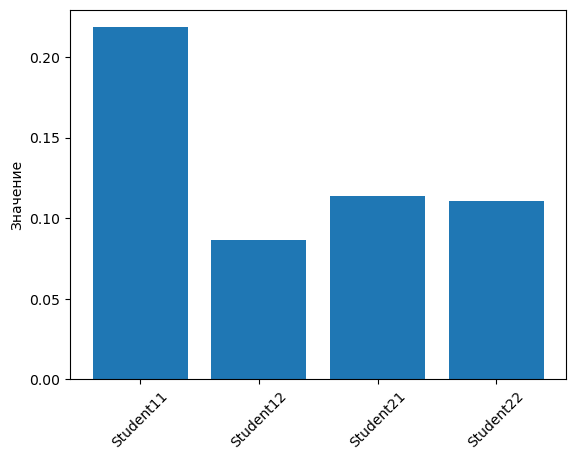

In [31]:
title = ['Student11', 'Student12', 'Student21', 'Student22']

plt.bar(title, MAE)
plt.xticks(rotation=45)
plt.ylabel('Значение')
plt.show()

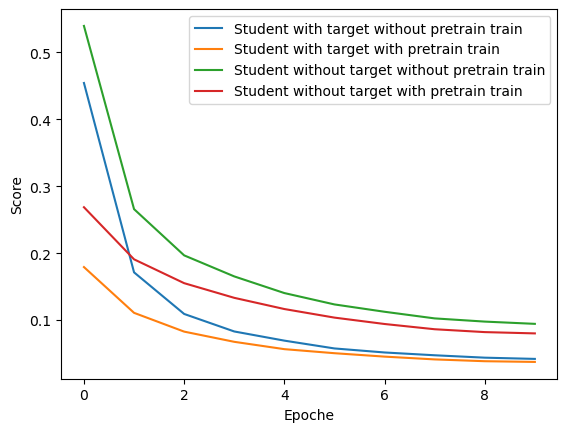

In [22]:
x = [i for i in range(len(train_score11))]

plt.plot(x, train_score11, label='Student with target without pretrain train')
plt.plot(x, train_score12, label='Student with target with pretrain train')
plt.plot(x, train_score21, label='Student without target without pretrain train')
plt.plot(x, train_score22, label='Student without target with pretrain train')
plt.legend()
plt.xlabel('Epoche')
plt.ylabel('Score')
plt.show()

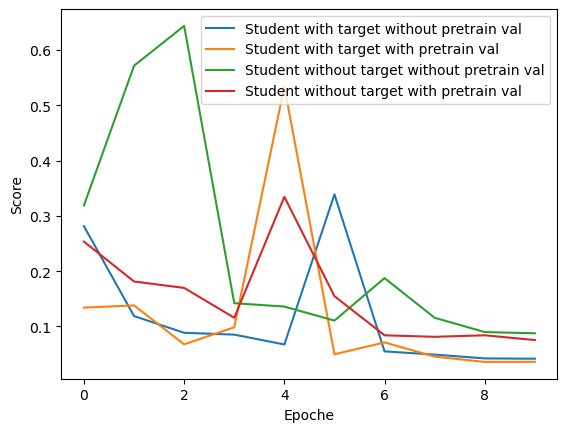

In [23]:
x = [i for i in range(len(train_score11))]

plt.plot(x, val_score11, label='Student with target without pretrain val')
plt.plot(x, val_score12, label='Student with target with pretrain val')
plt.plot(x, val_score21, label='Student without target without pretrain val')
plt.plot(x, val_score22, label='Student without target with pretrain val')
plt.legend()
plt.xlabel('Epoche')
plt.ylabel('Score')
plt.show()

In [32]:
MAE

[0.21849063746631145,
 0.0864029514292876,
 0.11387350743015608,
 0.11032040819525718]